# Week 7 — CNNs & U-Nets for microscopy: kernels, segmentation and saliency

**Course:** Data Science for Electron Microscopy — FAU Erlangen-Nürnberg
**Author:** Prof. Dr. Philipp Pelz
**Prerequisites:** Week 4 (validation, metrics) · Week 6 (neural networks, backprop, training loop)
**Time estimate:** ~120 minutes · runs on CPU in ~2–4 minutes end-to-end

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ECLIPSE-Lab/public_presentations/blob/main/data_science_for_em/notebooks/week07_cnn_segmentation.ipynb)

---

## What you will do

1. **Kernels as feature detectors** — apply hand-set kernels (Sobel, Laplacian, Gaussian) to a synthetic grain image and stack them into one convolutional layer.
2. **Check equivariance numerically** — convolution commutes with shifts, but not with rotations.
3. **Build a segmentation dataset** — synthetic noisy particle images with free pixel-perfect masks.
4. **Metrics before models** — IoU, Dice and the accuracy trap under class imbalance; a thresholding (Otsu) baseline.
5. **Train a tiny U-Net** (≈30 k parameters) with BCE + soft-Dice loss → test IoU/Dice.
6. **Explain a failure** — gradient saliency on false positives of an out-of-distribution image.
7. **Shortcut learning** — two classifiers with the same test accuracy; saliency, Grad-CAM and occlusion reveal which one learned the physics.

## Instructions

- Run cells top to bottom. Lines marked `# (try this yourself)` are the ones to edit.
- **Exercise** cells ship with a **working version** — read and predict what they do before running. `assert` statements check the key properties.
- A non-executable **Solution** cell (markdown) follows each exercise.


In [1]:
# --- Imports ---
# Colab: everything is pre-installed. On a bare environment uncomment:
# !pip install torch numpy scipy scikit-image matplotlib --quiet
import time
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.ndimage import convolve, gaussian_filter
from skimage.filters import threshold_otsu
import torch
import torch.nn as nn
import torch.nn.functional as F

np.random.seed(42)
torch.manual_seed(42)
torch.set_num_threads(1)   # tiny models: one thread avoids oversubscription and keeps results reproducible

%matplotlib inline
plt.rcParams['figure.dpi'] = 110
print("Imports OK — torch", torch.__version__)

Imports OK — torch 2.7.1+cu126


---

## Part 1 — Build a synthetic grain microstructure

We need an image that looks like an EM microstructure but is generated in Python, so we know the ground truth.
A 128×128 grayscale image with **five Voronoi grains** — different intensity per grain, sharp boundaries.

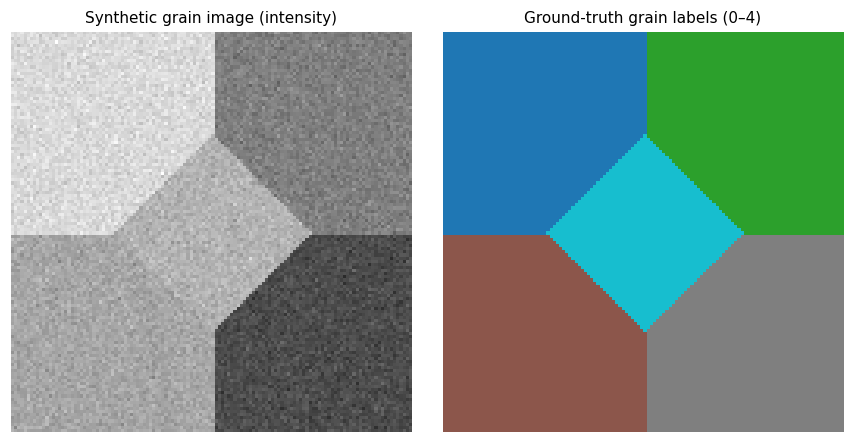

Image shape: (128, 128), dtype: float32
Intensity range: [0.165, 1.000]


In [2]:
# ── Build the synthetic grain image ──────────────────────────────────────────
H, W = 128, 128

# Seed points for 5 grains (row, col)
seeds = np.array([[32, 32], [32, 96], [96, 32], [96, 96], [64, 64]], dtype=float)

# Voronoi assignment: each pixel → nearest seed
yy, xx = np.mgrid[:H, :W]
pts = np.stack([yy.ravel(), xx.ravel()], axis=1)  # (N, 2)
dists = np.stack([
    np.sqrt((pts[:, 0] - s[0])**2 + (pts[:, 1] - s[1])**2)
    for s in seeds
], axis=1)  # (N, 5)
grain_id = np.argmin(dists, axis=1).reshape(H, W)  # 0..4

# Each grain gets a distinct average intensity + Gaussian noise
grain_intensities = [0.85, 0.50, 0.65, 0.30, 0.70]
image = np.zeros((H, W))
for g, intens in enumerate(grain_intensities):
    mask = grain_id == g
    image[mask] = intens + 0.04 * np.random.randn(np.sum(mask))

image = np.clip(image, 0.0, 1.0).astype(np.float32)

# ── Visualise ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(image, cmap='gray', vmin=0, vmax=1)
axes[0].set_title('Synthetic grain image (intensity)', fontsize=10)
axes[0].axis('off')

cmap5 = matplotlib.colormaps['tab10'].resampled(5)
axes[1].imshow(grain_id, cmap=cmap5, vmin=0, vmax=4)
axes[1].set_title('Ground-truth grain labels (0–4)', fontsize=10)
axes[1].axis('off')
plt.tight_layout()
plt.show()

print(f'Image shape: {image.shape}, dtype: {image.dtype}')
print(f'Intensity range: [{image.min():.3f}, {image.max():.3f}]')

---

## Part 2 — Hand-set kernels as feature detectors

A kernel is just a small matrix of weights. When we *convolve* it with the image, each output pixel encodes how strongly the kernel's pattern was present at that location.

Three classic kernels:

| Kernel | What it detects |
|---|---|
| Vertical Sobel | Left–right intensity change (vertical boundary) |
| Horizontal Sobel | Top–bottom intensity change (horizontal boundary) |
| Laplacian | Any local peak or valley (boundary in any direction) |
| Gaussian (5×5) | Smoothed (noise-reduced) version of the image |

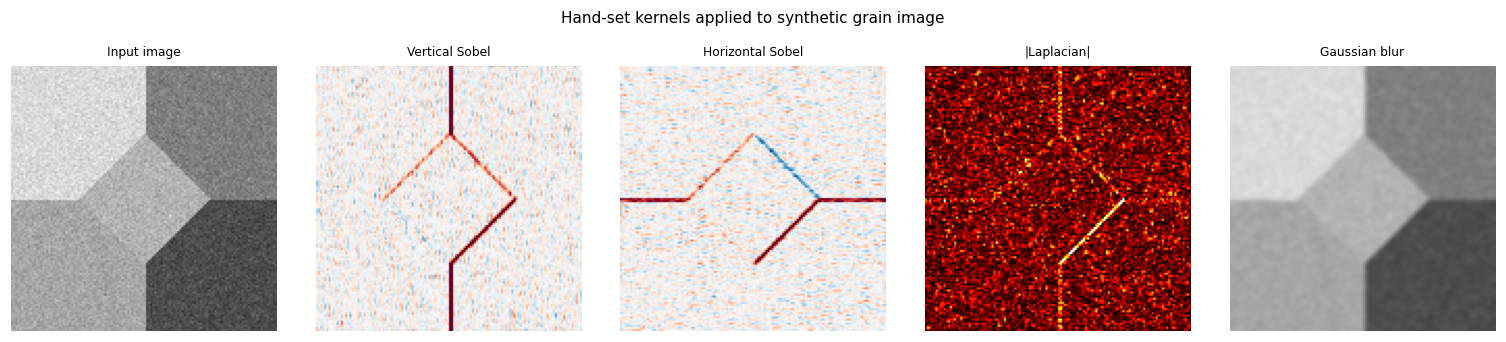

In [3]:
# ── Define hand-set kernels ───────────────────────────────────────────────
K_sobel_v = np.array([[-1, 0, 1],
                      [-2, 0, 2],
                      [-1, 0, 1]], dtype=np.float32)  # vertical edges

K_sobel_h = np.array([[-1, -2, -1],
                      [ 0,  0,  0],
                      [ 1,  2,  1]], dtype=np.float32)  # horizontal edges

K_laplace = np.array([[ 0, -1,  0],
                      [-1,  4, -1],
                      [ 0, -1,  0]], dtype=np.float32)  # any edge

# 5×5 Gaussian blur (hand-computed binomial weights, normalised)
_g1d = np.array([1, 4, 6, 4, 1], dtype=np.float32)
K_gaussian = np.outer(_g1d, _g1d)
K_gaussian /= K_gaussian.sum()  # normalise to preserve mean intensity

# ── Apply kernels ─────────────────────────────────────────────────────────
# scipy.ndimage.convolve applies the kernel to the image
feat_sv   = convolve(image, K_sobel_v,  mode='reflect')
feat_sh   = convolve(image, K_sobel_h,  mode='reflect')
feat_lap  = convolve(image, K_laplace,  mode='reflect')
feat_blur = convolve(image, K_gaussian, mode='reflect')

# ── Display ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(14, 3))
data = [
    (image,    'gray',   'Input image',         0.0, 1.0),
    (feat_sv,  'RdBu_r', 'Vertical Sobel',     -1.0, 1.0),
    (feat_sh,  'RdBu_r', 'Horizontal Sobel',   -1.0, 1.0),
    (np.abs(feat_lap), 'hot', '|Laplacian|',   0.0, 0.8),
    (feat_blur,'gray',   'Gaussian blur',        0.0, 1.0),
]
for ax, (d, cmap, title, vmin, vmax) in zip(axes, data):
    ax.imshow(d, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=8)
    ax.axis('off')
plt.suptitle('Hand-set kernels applied to synthetic grain image', y=1.02, fontsize=10)
plt.tight_layout()
plt.show()

# (try this yourself) — change K_sobel_v to K_sobel_h and check which boundary lights up
# (try this yourself) — apply np.abs(feat_sv) + np.abs(feat_sh) to get all edges at once

**What you should see:**
- *Vertical Sobel* fires (red/blue) along the vertical grain boundaries (left–right contrast changes).
- *Horizontal Sobel* fires along the horizontal boundaries.
- *|Laplacian|* fires at all boundaries, roughly equally in all directions.
- *Gaussian blur* smooths the noise without changing the large-scale grain structure.

---

## Part 3 — Multiple kernels = one convolutional layer

A convolutional layer applies **many kernels simultaneously**, one feature map per kernel: output shape $C_{out}\times H_{out}\times W_{out}$.
Stack the kernels into a weight tensor of shape `(C_out, C_in, kH, kW)` and use `F.conv2d`. In a trained CNN these weights are *learned* — that is the only difference.

Input shape:        torch.Size([1, 1, 128, 128])   → (batch, channels, H, W)
Weight shape:       torch.Size([4, 1, 3, 3]) → (C_out, C_in, kH, kW)
Feature maps shape: torch.Size([1, 4, 128, 128]) → (batch, C_out, H, W)


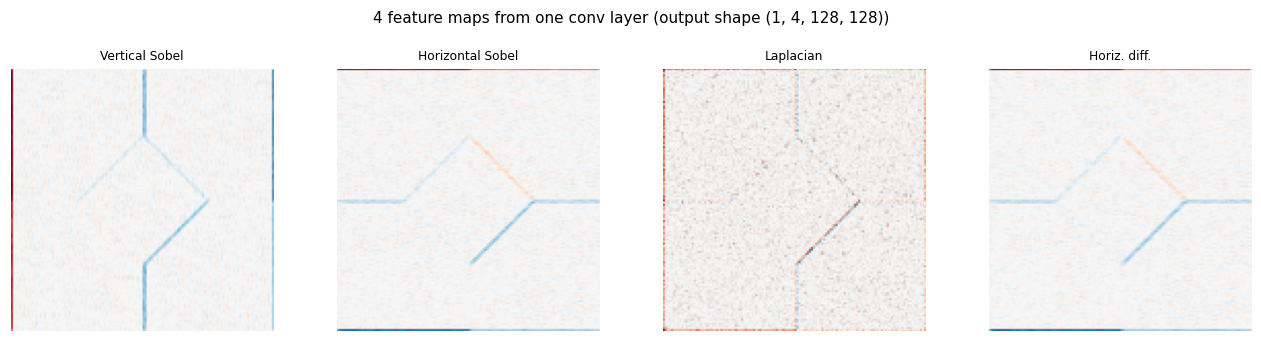

In [4]:
import torch.nn.functional as F

# ── Stack kernels into a weight tensor ──────────────────────────────────────
# PyTorch conv2d weight shape: (C_out, C_in, kH, kW)
# We have 4 kernels (C_out=4), 1 input channel (C_in=1), 3×3 kernels
kernels_3x3 = np.stack([
    K_sobel_v[np.newaxis],   # shape (1,3,3)
    K_sobel_h[np.newaxis],
    K_laplace[np.newaxis],
    np.array([[-1,-1,-1],[ 0, 0, 0],[ 1, 1, 1]], dtype=np.float32)[np.newaxis],  # horizontal difference
], axis=0)  # → (4, 1, 3, 3)

weight = torch.tensor(kernels_3x3)  # (4, 1, 3, 3)

# Image as (1, 1, H, W) tensor — batch size 1, 1 channel
x = torch.tensor(image[np.newaxis, np.newaxis])  # (1, 1, 128, 128)

# Apply convolution with padding=1 to preserve spatial size
with torch.no_grad():
    feat_maps = F.conv2d(x, weight, padding=1)  # (1, 4, 128, 128)

feat_maps_np = feat_maps[0].numpy()  # (4, 128, 128)

print(f'Input shape:        {x.shape}   → (batch, channels, H, W)')
print(f'Weight shape:       {weight.shape} → (C_out, C_in, kH, kW)')
print(f'Feature maps shape: {feat_maps.shape} → (batch, C_out, H, W)')

# ── Display ───────────────────────────────────────────────────────────────
names = ['Vertical Sobel', 'Horizontal Sobel', 'Laplacian', 'Horiz. diff.']
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for ax, fm, name in zip(axes, feat_maps_np, names):
    vmax = max(np.abs(fm).max(), 0.01)
    ax.imshow(fm, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    ax.set_title(name, fontsize=8)
    ax.axis('off')
plt.suptitle(f'4 feature maps from one conv layer (output shape {tuple(feat_maps.shape)})',
             y=1.02, fontsize=10)
plt.tight_layout()
plt.show()

# (try this yourself) — change padding=1 to padding=0 and see how the output shape changes
# (try this yourself) — print feat_maps_np[0].shape to confirm the spatial dimensions are preserved

---

## Part 4 — Equivariance, checked numerically

**Translation equivariance:** $f(T_\delta x) = T_\delta f(x)$ — shift the input, the feature map shifts by the same amount.
With circular padding this holds *exactly* for any kernel. For a **90° rotation** $R$ it does **not** hold: the vertical-edge detector becomes blind to edges that are now horizontal.
This is why rotation robustness in EM (crystal orientations, arbitrary specimen rotation) must come from **augmentation** (Week 8) or special *group-equivariant* architectures — the plain CNN does not give it for free.

max |f(Tx) - T f(x)|  (shift)    = 0.00e+00
max |f(Rx) - R f(x)|  (rotation) = 2.597


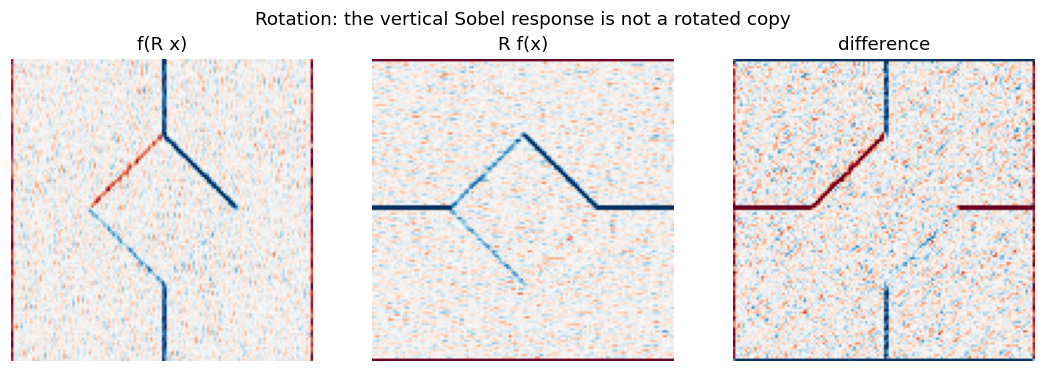

In [5]:
# ── Equivariance check with PyTorch conv2d (circular padding) ─────────────
w_sv = torch.tensor(K_sobel_v)[None, None]                  # (1,1,3,3)
f = lambda z: F.conv2d(F.pad(z, (1, 1, 1, 1), mode='circular'), w_sv)
x0 = torch.tensor(image)[None, None]

shift = lambda z: torch.roll(z, shifts=(9, 17), dims=(2, 3))
rot   = lambda z: torch.rot90(z, 1, dims=(2, 3))

with torch.no_grad():
    err_shift = (f(shift(x0)) - shift(f(x0))).abs().max().item()
    err_rot   = (f(rot(x0))   - rot(f(x0))).abs().max().item()

print(f"max |f(Tx) - T f(x)|  (shift)    = {err_shift:.2e}")
print(f"max |f(Rx) - R f(x)|  (rotation) = {err_rot:.3f}")
assert err_shift < 1e-5, "convolution should commute with circular shifts"
assert err_rot > 0.1,    "a vertical-edge kernel should NOT commute with 90° rotation"

fig, ax = plt.subplots(1, 3, figsize=(10, 3.4))
with torch.no_grad():
    for a, z, t in zip(ax, [f(rot(x0)), rot(f(x0)), f(rot(x0)) - rot(f(x0))],
                       ['f(R x)', 'R f(x)', 'difference']):
        a.imshow(z[0, 0], cmap='RdBu_r', vmin=-1, vmax=1); a.set_title(t); a.axis('off')
plt.suptitle('Rotation: the vertical Sobel response is not a rotated copy'); plt.tight_layout(); plt.show()
# (try this yourself): replace K_sobel_v by the (isotropic) Laplacian K_laplace — is it rotation-equivariant for 90°?

---

## Part 5 — A segmentation dataset with free labels

Real pixel labels cost hours per EM image. Here we simulate **bright nanoparticles on an unevenly illuminated, textured support**, with Poisson (shot) noise at a low dose — the ground-truth mask comes for free.

Honest validation (Week 4): train, validation and test images come from **different random "sessions"** (different generator seeds), never from overlapping tiles of the same image.

train (256, 48, 48) val (64, 48, 48) test (96, 48, 48)
particle (foreground) fraction: train 0.094, test 0.091


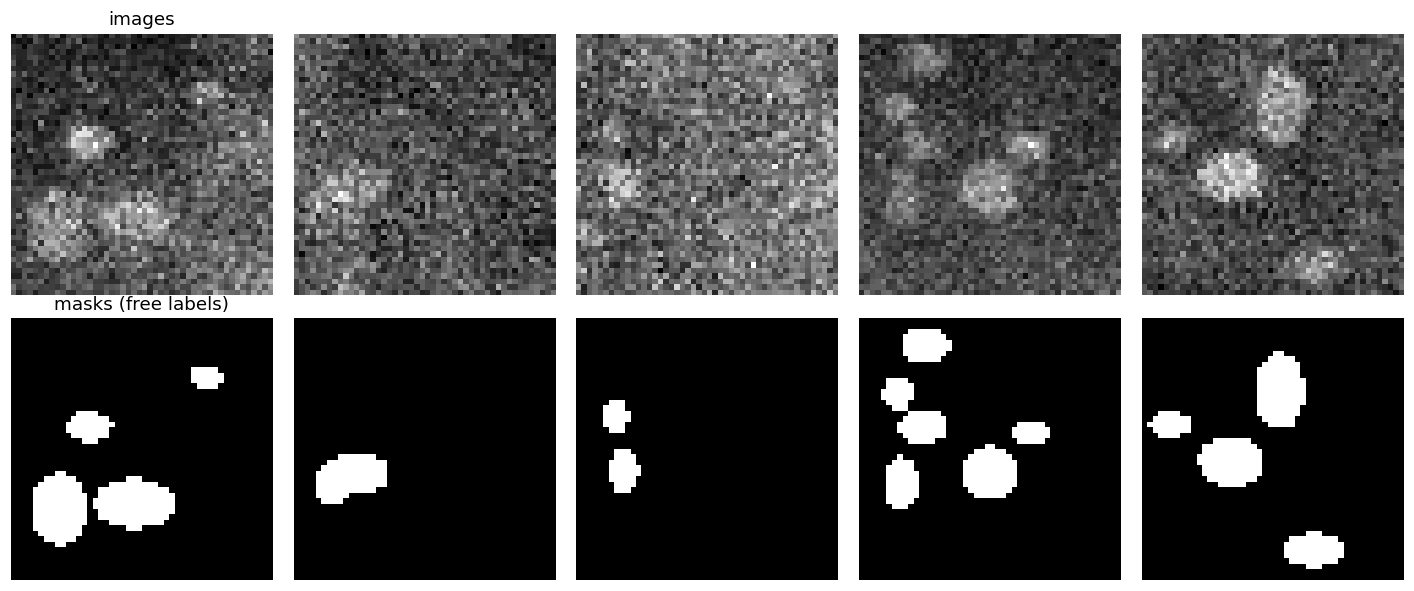

In [6]:
IMG, SEED = 48, 7

def make_particle_image(rng, n_min=2, n_max=6, r_min=2.5, r_max=6.0, dose=40.0, scratch=False, big=False):
    # Noisy EM-like image with bright particles on a textured, unevenly lit support.
    yy, xx = np.mgrid[:IMG, :IMG]
    bg = 0.30 + gaussian_filter(rng.standard_normal((IMG, IMG)), 3) * 0.25     # support texture
    g = rng.uniform(-0.12, 0.12, 2)
    bg += g[0] * (yy / IMG - 0.5) + g[1] * (xx / IMG - 0.5)                    # illumination gradient
    mask = np.zeros((IMG, IMG), bool)
    obj = np.zeros((IMG, IMG))
    for _ in range(rng.integers(n_min, n_max + 1)):
        r = rng.uniform(r_min, r_max)
        cy, cx = rng.uniform(r, IMG - r, 2)
        e = rng.uniform(0.7, 1.3)                                               # ellipticity
        d = ((yy - cy) / (r * e)) ** 2 + ((xx - cx) * e / r) ** 2 <= 1
        mask |= d
        obj[d] = np.maximum(obj[d], rng.uniform(0.15, 0.40))                    # variable contrast
    if big:                                                                     # OOD: oversized particle
        d = (yy - 24) ** 2 + (xx - 24) ** 2 <= 11 ** 2
        mask |= d; obj[d] = 0.30
    img = bg + gaussian_filter(obj, 0.8)                                        # finite resolution
    if scratch:                                                                 # OOD: bright scratch
        img = img + 0.30 * (np.abs(yy - 0.9 * xx - 5) < 1.2)
    img = np.clip(img, 0.01, None)
    img = rng.poisson(img * dose) / dose                                        # shot noise
    return img.astype(np.float32), mask.astype(np.float32)

def make_set(n, seed, **kw):
    rng = np.random.default_rng(seed)
    X, Y = zip(*[make_particle_image(rng, **kw) for _ in range(n)])
    return np.stack(X), np.stack(Y)

Xtr, Ytr = make_set(256, SEED)        # "session" A
Xva, Yva = make_set(64,  SEED + 1)    # "session" B
Xte, Yte = make_set(96,  SEED + 2)    # "session" C
print('train', Xtr.shape, 'val', Xva.shape, 'test', Xte.shape)
print(f'particle (foreground) fraction: train {Ytr.mean():.3f}, test {Yte.mean():.3f}')

fig, ax = plt.subplots(2, 5, figsize=(13, 5.4))
for i in range(5):
    ax[0, i].imshow(Xtr[i], cmap='gray'); ax[0, i].axis('off')
    ax[1, i].imshow(Ytr[i], cmap='gray'); ax[1, i].axis('off')
ax[0, 0].set_title('images'); ax[1, 0].set_title('masks (free labels)')
plt.tight_layout(); plt.show()

---

## Part 6 — Metrics before models: IoU, Dice, and the accuracy trap

For prediction $B$ and ground truth $A$ (sets of foreground pixels):

$$\mathrm{IoU} = \frac{|A\cap B|}{|A\cup B|}, \qquad \mathrm{Dice} = \frac{2|A\cap B|}{|A|+|B|} = \frac{2\,\mathrm{IoU}}{1+\mathrm{IoU}}.$$

Neither counts true-negative background pixels — which is exactly why they are honest under **class imbalance**. Pixel accuracy is not.
We also compute the classical baseline: Gaussian smoothing + **Otsu threshold** (baseline ladder: always beat the simple method first).

In [7]:
def iou_dice(pred, target):
    pred, target = pred.astype(bool), target.astype(bool)
    inter = (pred & target).sum()
    union = (pred | target).sum()
    return inter / max(union, 1), 2 * inter / max(pred.sum() + target.sum(), 1)

def pixel_acc(pred, target):
    return (pred.astype(bool) == target.astype(bool)).mean()

P_bg   = np.zeros_like(Yte, dtype=bool)                                  # predict "no particle" everywhere
P_otsu = np.stack([gaussian_filter(x, 1) > threshold_otsu(gaussian_filter(x, 1)) for x in Xte])

for name, P in [('all background', P_bg), ('smoothed Otsu', P_otsu)]:
    iou, dice = iou_dice(P, Yte)
    print(f'{name:15s}: pixel acc = {pixel_acc(P, Yte):.3f}   IoU = {iou:.3f}   Dice = {dice:.3f}')
print('\nPredicting NOTHING already gives ~91% pixel accuracy. Report IoU/Dice for the minority class.')

all background : pixel acc = 0.909   IoU = 0.000   Dice = 0.000
smoothed Otsu  : pixel acc = 0.909   IoU = 0.480   Dice = 0.649

Predicting NOTHING already gives ~91% pixel accuracy. Report IoU/Dice for the minority class.


---

## Exercise 1 — The soft-Dice loss

IoU and Dice are computed on thresholded masks, so they are **not differentiable**. The *soft Dice* replaces the binary prediction by the predicted probability $p_i=\sigma(z_i)$:

$$\mathcal{L}_\text{Dice} = 1 - \frac{2\sum_i p_i y_i + \epsilon}{\sum_i p_i + \sum_i y_i + \epsilon}.$$

Because it is normalised by the foreground size, a model cannot minimise it by predicting "all background" — a direct remedy for class imbalance (alternatives: class-weighted cross-entropy via `pos_weight`, focal loss).

**Task:** read the working version below, predict the three assertion values, then run it.
**(try this yourself):** the cell also prints the plain BCE of the all-background prediction and its class-weighted version (`pos_weight`). Where does the BCE value come from, and what does `pos_weight` change?

In [8]:
def soft_dice_loss(logits, target, eps=1.0):
    p = torch.sigmoid(logits)
    inter = (p * target).sum((1, 2, 3))
    tot = p.sum((1, 2, 3)) + target.sum((1, 2, 3))
    return (1 - (2 * inter + eps) / (tot + eps)).mean()

y = torch.tensor(Ytr[:8, None])                    # 8 real masks, shape (8,1,48,48)
perfect   = (y * 2 - 1) * 20.0                     # huge logits of the right sign
all_bg    = torch.full_like(y, -20.0)              # "predict nothing"
coin_flip = torch.zeros_like(y)                    # p = 0.5 everywhere

l_perf, l_bg, l_coin = [soft_dice_loss(z, y).item() for z in (perfect, all_bg, coin_flip)]
print(f'perfect: {l_perf:.3f}   all-background: {l_bg:.3f}   p=0.5 everywhere: {l_coin:.3f}')
f_fg = y.mean().item()
bce    = F.binary_cross_entropy_with_logits(all_bg, y).item()
bce_pw = F.binary_cross_entropy_with_logits(all_bg, y, pos_weight=torch.tensor((1 - f_fg) / f_fg)).item()
print(f'foreground fraction {f_fg:.3f} | BCE all-background {bce:.2f} | BCE with pos_weight={(1 - f_fg) / f_fg:.1f}: {bce_pw:.2f}')

assert l_perf < 0.01, 'a perfect prediction must give ~0 Dice loss'
assert l_bg > 0.95,   'predicting nothing must be penalised (~1)'
assert l_perf < l_coin < l_bg

perfect: 0.000   all-background: 0.993   p=0.5 everywhere: 0.852
foreground fraction 0.090 | BCE all-background 1.79 | BCE with pos_weight=10.2: 18.21


### Solution

*(Non-executable — read after running the exercise.)*

```python
# perfect: 0.000   all-background: ~0.99   p=0.5 everywhere: ~0.85
# BCE all-background ≈ 20 × f_fg ≈ 1.8: ALL of it comes from the ~9% particle pixels
# (logit -20 on a positive pixel costs 20 nats), the 91% background pixels cost ~0.
# Cross-entropy is a per-pixel *average*, so the particle class carries only ~9% of the weight;
# pos_weight = (1-f)/f ≈ 10 multiplies the positive-pixel terms and restores balance (BCE ≈ 18).
# Dice is a ratio over the foreground and ignores true negatives altogether.
# Common practice: loss = BCE + Dice (BCE gives smooth per-pixel gradients early in
# training, Dice keeps the minority class in focus).
```

---

## Part 7 — A tiny U-Net

Encoder (conv–BN–ReLU ×2, max-pool) → bottleneck → decoder (transposed conv upsampling, **concatenate the skip connection**, conv ×2) → 1×1 conv to one logit per pixel.
Two resolution levels are enough for 48×48 images. `use_skips=False` removes the skip connections (for the ablation exercise).

In [9]:
def block(ci, co):
    return nn.Sequential(
        nn.Conv2d(ci, co, 3, padding=1), nn.BatchNorm2d(co), nn.ReLU(inplace=True),
        nn.Conv2d(co, co, 3, padding=1), nn.BatchNorm2d(co), nn.ReLU(inplace=True))

class TinyUNet(nn.Module):
    def __init__(self, c=8, use_skips=True):
        super().__init__()
        self.use_skips = use_skips
        k = 2 if use_skips else 1                       # concatenation doubles the decoder input channels
        self.enc1, self.enc2, self.bott = block(1, c), block(c, 2 * c), block(2 * c, 4 * c)
        self.up2 = nn.ConvTranspose2d(4 * c, 2 * c, 2, stride=2)
        self.dec2 = block(k * 2 * c, 2 * c)
        self.up1 = nn.ConvTranspose2d(2 * c, c, 2, stride=2)
        self.dec1 = block(k * c, c)
        self.head = nn.Conv2d(c, 1, 1)                  # one logit per pixel

    def forward(self, x):
        e1 = self.enc1(x)                               # (c,  48, 48)
        e2 = self.enc2(F.max_pool2d(e1, 2))             # (2c, 24, 24)
        b  = self.bott(F.max_pool2d(e2, 2))             # (4c, 12, 12)  bottleneck: most context
        d2 = self.up2(b)                                # (2c, 24, 24)
        d2 = self.dec2(torch.cat([d2, e2], 1) if self.use_skips else d2)
        d1 = self.up1(d2)                               # (c,  48, 48)
        d1 = self.dec1(torch.cat([d1, e1], 1) if self.use_skips else d1)
        return self.head(d1)                            # (1,  48, 48)

print('parameters:', sum(p.numel() for p in TinyUNet().parameters()))
print('output shape for a (4,1,48,48) batch:', tuple(TinyUNet()(torch.zeros(4, 1, 48, 48)).shape))

parameters: 29641
output shape for a (4,1,48,48) batch: (4, 1, 48, 48)


training time: 32 s


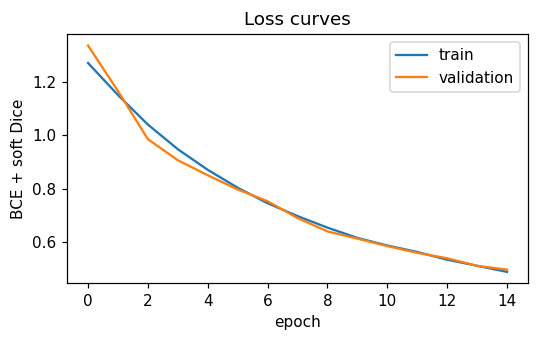

In [10]:
def train_unet(Xtr, Ytr, epochs=15, lr=3e-3, dice_w=1.0, use_skips=True):
    torch.manual_seed(0); np.random.seed(0)
    model = TinyUNet(use_skips=use_skips)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    Xt, Yt = torch.tensor(Xtr[:, None]), torch.tensor(Ytr[:, None])
    Xv, Yv = torch.tensor(Xva[:, None]), torch.tensor(Yva[:, None])
    hist = []
    for ep in range(epochs):
        model.train(); perm = torch.randperm(len(Xt)); tl = 0.0
        for i in range(0, len(Xt), 16):
            idx = perm[i:i + 16]; xb, yb = Xt[idx], Yt[idx]
            if np.random.rand() < 0.5:                  # mirror augmentation (image AND mask!)
                xb, yb = xb.flip(-1), yb.flip(-1)
            lo = model(xb)
            loss = F.binary_cross_entropy_with_logits(lo, yb) + dice_w * soft_dice_loss(lo, yb)
            opt.zero_grad(); loss.backward(); opt.step()
            tl += loss.item() * len(idx)
        model.eval()
        with torch.no_grad():
            lv = model(Xv)
            vl = (F.binary_cross_entropy_with_logits(lv, Yv) + dice_w * soft_dice_loss(lv, Yv)).item()
        hist.append((tl / len(Xt), vl))
    return model.eval(), np.array(hist)

def predict(model, X):
    with torch.no_grad():
        return (torch.sigmoid(model(torch.tensor(X[:, None])))[:, 0] > 0.5).numpy()

t0 = time.time()
unet, hist = train_unet(Xtr, Ytr)
print(f'training time: {time.time() - t0:.0f} s')

plt.figure(figsize=(5, 3.2))
plt.plot(hist[:, 0], label='train'); plt.plot(hist[:, 1], label='validation')
plt.xlabel('epoch'); plt.ylabel('BCE + soft Dice'); plt.legend(); plt.title('Loss curves'); plt.tight_layout(); plt.show()

smoothed Otsu : pixel acc 0.909  IoU 0.480  Dice 0.649
tiny U-Net    : pixel acc 0.984  IoU 0.836  Dice 0.910
per-image IoU: median 0.834, worst 0.716 (image 11)


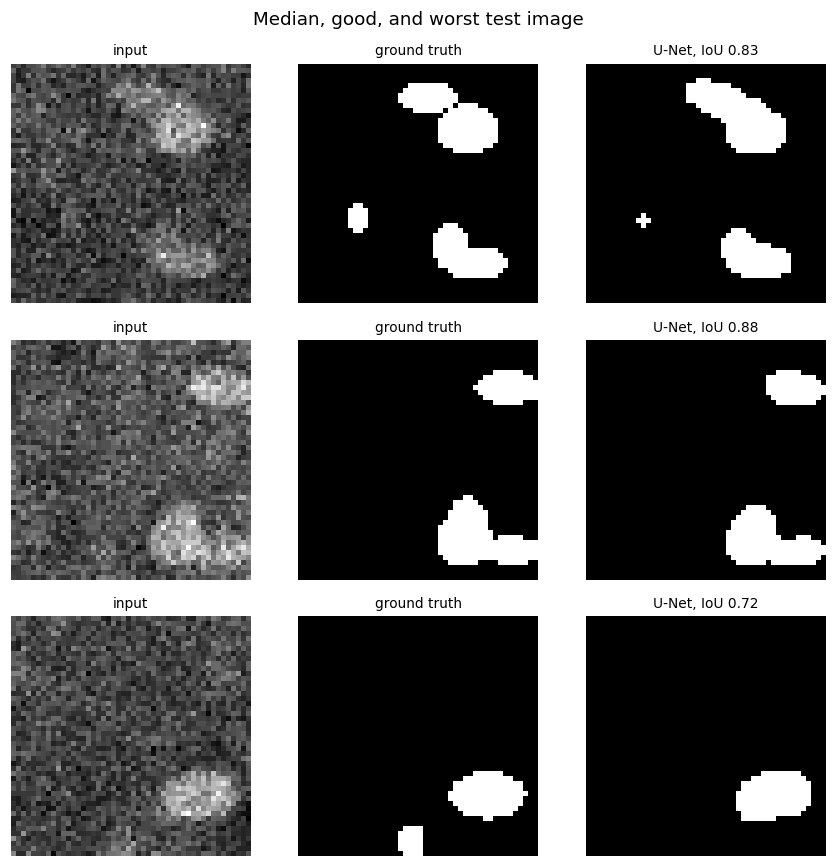

In [11]:
P_unet = predict(unet, Xte)
iou_u, dice_u = iou_dice(P_unet, Yte)
iou_o, dice_o = iou_dice(P_otsu, Yte)
print(f'smoothed Otsu : pixel acc {pixel_acc(P_otsu, Yte):.3f}  IoU {iou_o:.3f}  Dice {dice_o:.3f}')
print(f'tiny U-Net    : pixel acc {pixel_acc(P_unet, Yte):.3f}  IoU {iou_u:.3f}  Dice {dice_u:.3f}')

per_img = np.array([iou_dice(P_unet[i], Yte[i])[0] for i in range(len(Xte))])
print(f'per-image IoU: median {np.median(per_img):.3f}, worst {per_img.min():.3f} (image {per_img.argmin()})')

assert iou_u > 0.7,   'the U-Net should clearly segment the particles'
assert iou_u > iou_o, 'the U-Net should beat the thresholding baseline'

order = np.argsort(per_img)
fig, ax = plt.subplots(3, 3, figsize=(8, 8))
for r, i in enumerate([order[len(order) // 2], order[3 * len(order) // 4], order[0]]):
    for c, (z, t) in enumerate([(Xte[i], 'input'), (Yte[i], 'ground truth'), (P_unet[i], f'U-Net, IoU {per_img[i]:.2f}')]):
        ax[r, c].imshow(z, cmap='gray'); ax[r, c].set_title(t, fontsize=9); ax[r, c].axis('off')
plt.suptitle('Median, good, and worst test image'); plt.tight_layout(); plt.show()

**What you should see:** test IoU ≈ 0.84 / Dice ≈ 0.91 for the U-Net versus IoU ≈ 0.48 for smoothed Otsu (the illumination gradient and support texture defeat a global threshold).
The worst test image typically contains a **low-contrast particle that is missed entirely** — always look at the failures, not just the mean.

---

## Part 8 — Explaining a failure with gradient saliency

Now an **out-of-distribution** image: a bright **scratch** (never seen in training) and an **oversized particle** (larger than any training particle).
For the false-positive pixels we compute the saliency $\left|\partial \sum_{i\in FP} z_i / \partial x\right|$ — which input pixels drove the wrong decision?

OOD image: IoU 0.758, false-positive pixels 101, false-negative pixels 33
mean saliency ON the scratch: 0.071   elsewhere: 0.018


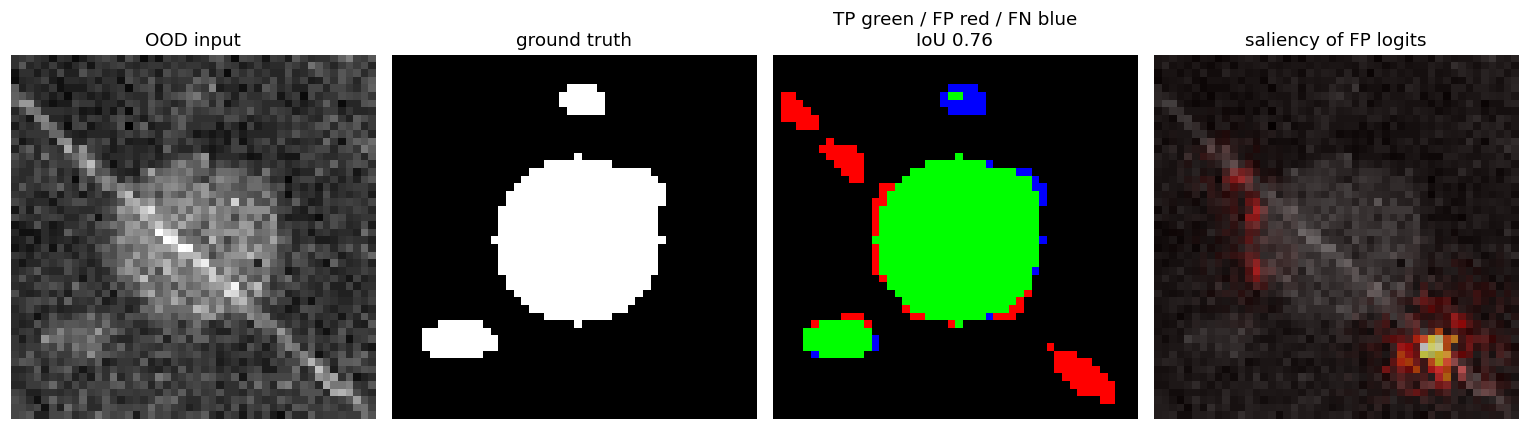

In [12]:
rng = np.random.default_rng(99)
xs, ys = make_particle_image(rng, scratch=True, big=True)
ps = predict(unet, xs[None])[0]
fp = ps & ~ys.astype(bool)
fn = ~ps & ys.astype(bool)
iou_s, _ = iou_dice(ps, ys)
print(f'OOD image: IoU {iou_s:.3f}, false-positive pixels {fp.sum()}, false-negative pixels {fn.sum()}')

x = torch.tensor(xs[None, None], requires_grad=True)
logits = unet(x)[0, 0]
logits[torch.tensor(fp)].sum().backward()           # gradient of the summed FP logits w.r.t. the input
sal = x.grad[0, 0].abs().numpy(); sal /= sal.max()

scratch_px = np.abs(np.mgrid[:IMG, :IMG][0] - 0.9 * np.mgrid[:IMG, :IMG][1] - 5) < 1.2
print(f'mean saliency ON the scratch: {sal[scratch_px].mean():.3f}   elsewhere: {sal[~scratch_px].mean():.3f}')
assert sal[scratch_px].mean() > sal[~scratch_px].mean()

fig, ax = plt.subplots(1, 4, figsize=(14, 3.8))
ax[0].imshow(xs, cmap='gray'); ax[0].set_title('OOD input')
ax[1].imshow(ys, cmap='gray'); ax[1].set_title('ground truth')
ax[2].imshow(np.dstack([fp, ps & ys.astype(bool), fn]).astype(float)); ax[2].set_title(f'TP green / FP red / FN blue\nIoU {iou_s:.2f}')
ax[3].imshow(xs, cmap='gray'); ax[3].imshow(sal, cmap='hot', alpha=0.6); ax[3].set_title('saliency of FP logits')
for a in ax: a.axis('off')
plt.tight_layout(); plt.show()

**Reading the map:** the evidence for the false positives sits *on the scratch itself*. The U-Net has learned "locally bright blob = particle"; within its receptive field (a few tens of pixels) a bright line segment looks like an elongated particle. Saliency does not fix the model — it tells you **what data to add** (scratches labelled as background, Week 8 augmentation) and that this model must not be trusted on scratched specimens.

---

## Exercise 2 — Ablations *(try this yourself)*

Set `RUN_ABLATION = True` to retrain (≈30–60 s each) and compare:
1. `use_skips=False` — a U-Net *without* skip connections.
2. `dice_w=0.0` — plain BCE, no Dice term.

Predict first: which one hurts IoU more on *these* images, and why?

In [13]:
RUN_ABLATION = False   # (try this yourself): set to True

if RUN_ABLATION:
    for kw in [dict(use_skips=False), dict(dice_w=0.0)]:
        m, _ = train_unet(Xtr, Ytr, **kw)
        iou, dice = iou_dice(predict(m, Xte), Yte)
        print(f'{kw}: IoU {iou:.3f}  Dice {dice:.3f}   (reference U-Net: IoU {iou_u:.3f})')
else:
    print('Ablation skipped — set RUN_ABLATION = True to run it.')

Ablation skipped — set RUN_ABLATION = True to run it.


### Solution

*(Non-executable.)*

```python
# Result (SEED=7, CPU, 15 epochs):
#   use_skips=False : IoU ≈ 0.84  -> essentially no loss here!
#   dice_w=0.0      : IoU = 0.00, pixel accuracy 0.909 -> plain BCE collapsed to "all background"
#                     within the 15-epoch budget: the class-imbalance trap, live.
# Why do skips not matter here? The particles are compact blobs of radius 2.5–6 px and the
# bottleneck is still 12×12 — the decoder can re-create blob shapes from coarse features.
# Skip connections pay off when *boundary position* matters at the pixel level: thin grain
# boundaries, cracks, dislocation lines, and deeper U-Nets (4–5 pooling levels) on large images.
# Lesson: ablations are task-dependent — test the claim on YOUR data instead of assuming it.
```

---

## Part 9 — Shortcut learning: same accuracy, different physics

A defect classifier (class 1 = small, faint bright disk somewhere in the image). In the **shortcut** training set every class-1 image *also* has a **dark 6×6 corner** — think of a scan-start shadow or a detector-edge artefact present in every image of the session in which the defective specimen was recorded. The **clean** model is trained on the same images without the artefact.

We then test on (a) images *with* the artefact (the training distribution) and (b) the deployment case — defects, no artefact.

In [14]:
S, CORNER, R_DEF, AMP = 32, 6, 4, 0.15
yy32, xx32 = np.mgrid[:S, :S]

def bg32(rng, n):
    return np.stack([np.clip(0.35 + rng.standard_normal((S, S)) * 0.12
                             + gaussian_filter(rng.standard_normal((S, S)) * 0.10, 2.5), 0, 1)
                     for _ in range(n)]).astype(np.float32)

def add_defect(rng, X):
    X = X.copy(); masks = np.zeros((len(X), S, S), bool)
    for i in range(len(X)):
        cy, cx = rng.uniform(R_DEF + 2, S - R_DEF - 2, 2)
        d = (yy32 - cy) ** 2 + (xx32 - cx) ** 2 <= R_DEF ** 2
        X[i][d] += AMP; masks[i] = d
    return np.clip(X, 0, 1), masks

def add_corner(X):
    X = X.copy(); X[:, :CORNER, :CORNER] = 0.0      # dark scan-start / detector-shadow artefact
    return X

def build32(seed, n, artifact):
    rng = np.random.default_rng(seed)
    X0 = bg32(rng, n)
    X1, m = add_defect(rng, bg32(rng, n))
    if artifact:
        X1 = add_corner(X1)
    return np.concatenate([X0, X1]), np.array([0] * n + [1] * n), m

class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 32, 3, padding=1), nn.ReLU())
        self.head = nn.Linear(32, 2)
    def forward(self, x):
        return self.head(self.features(x).mean((2, 3)))   # global average pooling -> invariant score

def train_cls(X, y, epochs=25):
    torch.manual_seed(0)
    m = SmallCNN(); opt = torch.optim.Adam(m.parameters(), 1e-3)
    Xt, yt = torch.tensor(X[:, None]), torch.tensor(y)
    for _ in range(epochs):
        perm = torch.randperm(len(X))
        for i in range(0, len(X), 32):
            idx = perm[i:i + 32]
            loss = F.cross_entropy(m(Xt[idx]), yt[idx]); opt.zero_grad(); loss.backward(); opt.step()
    return m.eval()

def accuracy(m, X, y):
    with torch.no_grad():
        return (m(torch.tensor(X[:, None])).argmax(1).numpy() == y).mean()

Xc, yc, _ = build32(1, 200, artifact=False)
Xs, ys_, _ = build32(1, 200, artifact=True)
X_iid, y_te, m_iid = build32(2, 50, artifact=True)     # test set like the shortcut training data
X_dep, _, _        = build32(2, 50, artifact=False)    # deployment: defects, no artefact

t0 = time.time()
clean, short = train_cls(Xc, yc), train_cls(Xs, ys_)
print(f'training time: {time.time() - t0:.0f} s')
acc = {n: (accuracy(m, X_iid, y_te), accuracy(m, X_dep, y_te)) for n, m in [('clean', clean), ('shortcut', short)]}
for n, (a1, a2) in acc.items():
    print(f'{n:8s}: accuracy with artefact {a1:.2f}   |   deployment (no artefact) {a2:.2f}')
assert acc['shortcut'][0] > 0.95 and acc['shortcut'][1] < 0.7, 'shortcut model: perfect in-distribution, ~chance in deployment'
assert acc['clean'][1] > 0.85

training time: 15 s
clean   : accuracy with artefact 0.94   |   deployment (no artefact) 0.94
shortcut: accuracy with artefact 1.00   |   deployment (no artefact) 0.50


Three explanation methods for the class-1 logit $z_1$:

| Method | Computation | Resolution |
|---|---|---|
| **Gradient saliency** | $\lvert\partial z_1/\partial x\rvert$ — one backward pass | pixel, noisy |
| **Grad-CAM** | weights $\alpha_k=\text{mean}_{ij}\,\partial z_1/\partial A^k_{ij}$ on the last conv maps $A^k$; $\text{ReLU}(\sum_k\alpha_kA^k)$, upsampled | last conv layer (8×8), smooth |
| **Occlusion** | grey out a patch, record the drop in $p(\text{class 1})$ | patch size, model-agnostic, slow |

clean   : attribution mass in corner (3.5% of pixels) — gradient 0.00, Grad-CAM 0.00, occlusion 0.00;  gradient mass in defect 0.19


shortcut: attribution mass in corner (3.5% of pixels) — gradient 0.30, Grad-CAM 0.34, occlusion 0.76;  gradient mass in defect 0.03


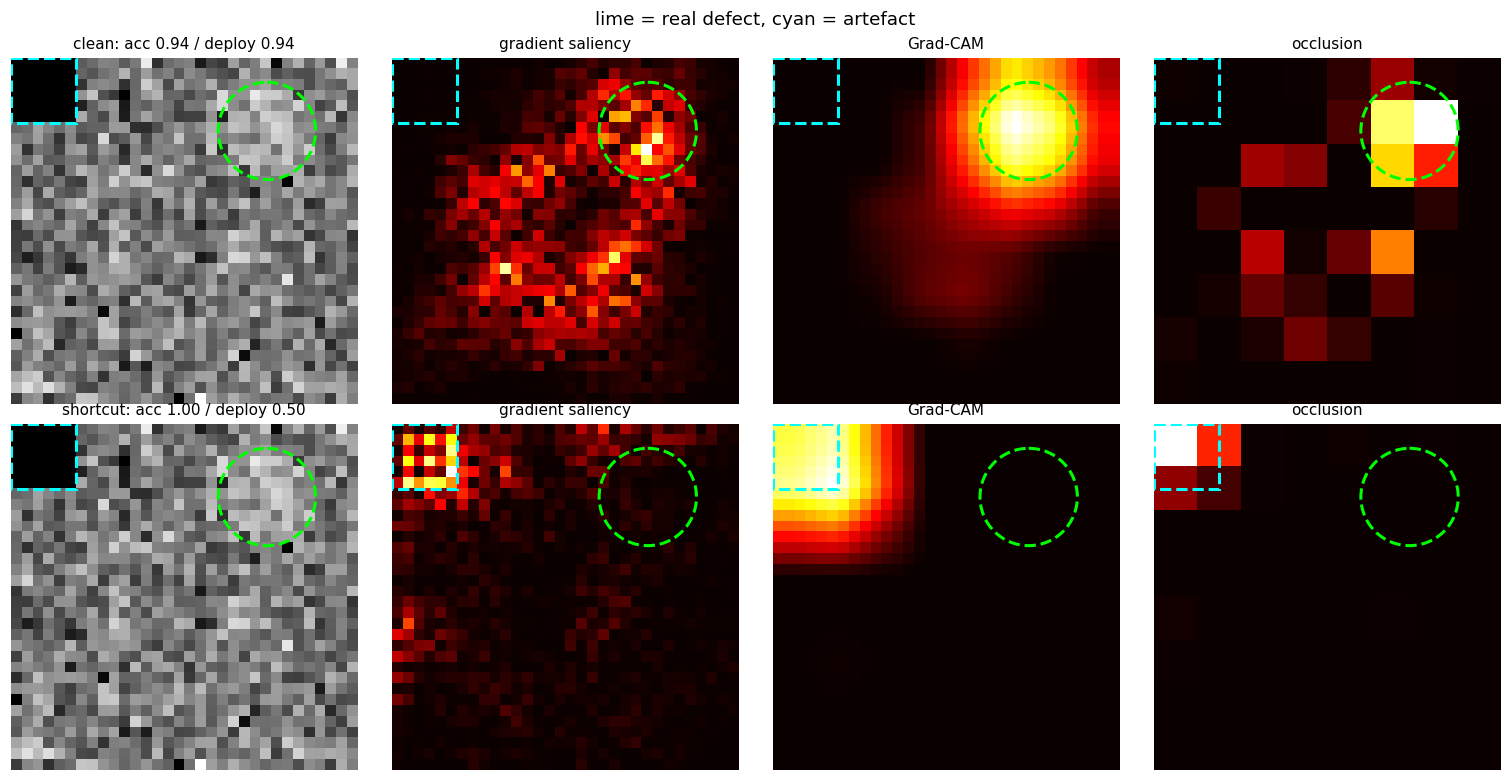

In [15]:
def grad_saliency(m, x):
    x = torch.tensor(x[None, None], requires_grad=True)
    m(x)[0, 1].backward()
    return x.grad[0, 0].abs().numpy()

def grad_cam(m, x):
    A = m.features(torch.tensor(x[None, None]))       # last conv feature maps (1, 32, 8, 8)
    A.retain_grad()
    m.head(A.mean((2, 3)))[0, 1].backward()
    w = A.grad.mean((2, 3), keepdim=True)              # alpha_k: channel importance
    cam = F.relu((w * A).sum(1, keepdim=True))
    return F.interpolate(cam, size=(S, S), mode='bilinear', align_corners=False)[0, 0].detach().numpy()

def occlusion(m, x, patch=4, value=0.35):              # (try this yourself): patch=2 or 8, value=0.0
    with torch.no_grad():
        p0 = torch.softmax(m(torch.tensor(x[None, None])), 1)[0, 1].item()
        smap = np.zeros((S, S))
        for r in range(0, S, patch):
            for c in range(0, S, patch):
                xo = x.copy(); xo[r:r + patch, c:c + patch] = value
                p1 = torch.softmax(m(torch.tensor(xo[None, None])), 1)[0, 1].item()
                smap[r:r + patch, c:c + patch] = max(p0 - p1, 0)
    return smap

corner = np.zeros((S, S), bool); corner[:CORNER, :CORNER] = True
frac = {}
for name, m in [('clean', clean), ('shortcut', short)]:
    fr = {'grad': [], 'cam': [], 'occ': [], 'grad_defect': []}
    for j, i in enumerate(range(50, 100)):             # class-1 test images (defect + artefact)
        for key, fn in [('grad', grad_saliency), ('cam', grad_cam), ('occ', occlusion)]:
            z = fn(m, X_iid[i]); z = z / (z.sum() + 1e-12)   # treat each map as a distribution
            fr[key].append(z[corner].sum())
            if key == 'grad':
                fr['grad_defect'].append(z[m_iid[j]].sum())
    frac[name] = {k: np.mean(v) for k, v in fr.items()}
    print(f"{name:8s}: attribution mass in corner (3.5% of pixels) — gradient {frac[name]['grad']:.2f}, "
          f"Grad-CAM {frac[name]['cam']:.2f}, occlusion {frac[name]['occ']:.2f};  gradient mass in defect {frac[name]['grad_defect']:.2f}")
assert frac['shortcut']['grad'] > 3 * frac['clean']['grad'] + 0.05

i0 = 50 + int(np.argmax([mk[:16, :16].sum() == 0 for mk in m_iid]))   # a defect away from the corner
fig, ax = plt.subplots(2, 4, figsize=(14, 7.2))
for r, (name, m) in enumerate([('clean', clean), ('shortcut', short)]):
    x = X_iid[i0]
    for a, (z, cm, t) in zip(ax[r], [(x, 'gray', f'{name}: acc {acc[name][0]:.2f} / deploy {acc[name][1]:.2f}'),
                                      (grad_saliency(m, x), 'hot', 'gradient saliency'),
                                      (grad_cam(m, x), 'hot', 'Grad-CAM'),
                                      (occlusion(m, x), 'hot', 'occlusion')]):
        a.imshow(z, cmap=cm); a.set_title(t, fontsize=10); a.axis('off')
        a.add_patch(mpatches.Rectangle((-0.5, -0.5), CORNER, CORNER, ec='cyan', fc='none', lw=2, ls='--'))
        cy, cx = np.argwhere(m_iid[i0 - 50]).mean(0)
        a.add_patch(mpatches.Circle((cx, cy), R_DEF + 0.5, ec='lime', fc='none', lw=2, ls='--'))
plt.suptitle('lime = real defect, cyan = artefact'); plt.tight_layout(); plt.show()

**What you should see:** both models look excellent on the in-distribution test set (0.94 vs 1.00), but the shortcut model drops to **chance (0.50)** in deployment. All three explanation methods put the shortcut model's evidence in the **corner** and none on the defect; the clean model's evidence sits on the defect. Accuracy on a test set drawn from the same sessions cannot detect this — it is the Week 4 leakage problem in disguise.

---

## Exercise 3 — Sanity check for saliency (Adebayo et al., 2018)

A saliency method is only useful if it depends on **what the model learned**. Randomise the weights and recompute: if the map still looks the same, the method is showing image structure (edges, bright spots), not model reasoning.

Working version below — run it, then **(try this yourself)**: randomise only the `head` layer and compare.

correlation trained vs randomised saliency: 0.01
corner mass: trained 0.28   randomised 0.03


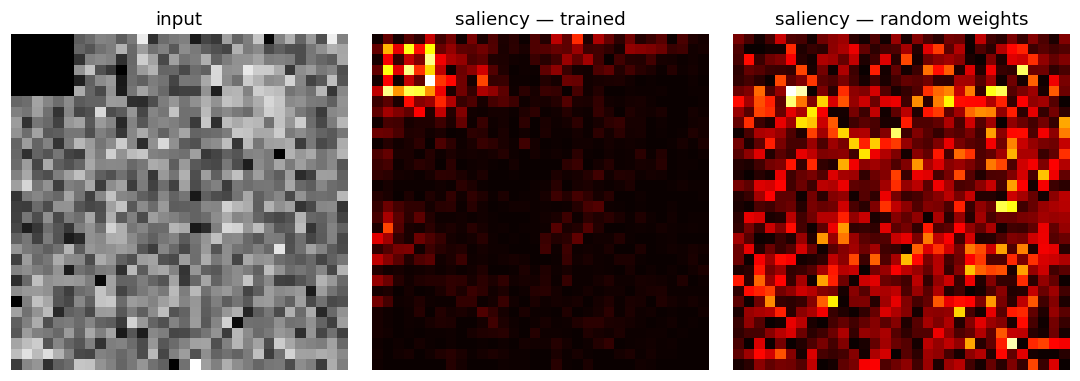

In [16]:
import copy
rand_model = copy.deepcopy(short)
torch.manual_seed(123)
for mod in rand_model.modules():                       # (try this yourself): only rand_model.head
    if isinstance(mod, (nn.Conv2d, nn.Linear)):
        mod.reset_parameters()

x = X_iid[i0]
s_trained = grad_saliency(short, x)
s_random  = grad_saliency(rand_model, x)
rho = np.corrcoef(s_trained.ravel(), s_random.ravel())[0, 1]
print(f'correlation trained vs randomised saliency: {rho:.2f}')
print(f"corner mass: trained {s_trained[corner].sum() / s_trained.sum():.2f}   randomised {s_random[corner].sum() / s_random.sum():.2f}")
assert rho < 0.5, 'gradient saliency should change substantially when the weights are randomised'

fig, ax = plt.subplots(1, 3, figsize=(10, 3.4))
for a, z, t in zip(ax, [x, s_trained, s_random], ['input', 'saliency — trained', 'saliency — random weights']):
    a.imshow(z, cmap='gray' if t == 'input' else 'hot'); a.set_title(t); a.axis('off')
plt.tight_layout(); plt.show()

### Solution

*(Non-executable.)*

```python
# The randomised model's saliency is spatially unstructured (low correlation with the trained map,
# corner mass drops to roughly the corner's area fraction). Gradient saliency therefore passes
# the model-randomisation test: the corner hotspot of the trained shortcut model is a property
# of what the model learned, not of the image. Randomising only the head changes the maps less
# (the conv features still respond to the dark corner) — cascading randomisation from the top
# layer down is the full protocol.
```

---

## Summary

| Concept | What you did | Key number (SEED=7) |
|---|---|---|
| Convolution = learned local filter | Sobel/Laplacian feature maps, stacked as one layer | 3×3 kernel = 9 weights, any image size |
| Equivariance | shift commutes exactly, 90° rotation does not | error 0 vs ≈3 |
| Class imbalance | predicting nothing | 91% pixel accuracy, IoU 0 |
| Baseline ladder | smoothed Otsu threshold | IoU ≈ 0.48 |
| Tiny U-Net | 30 k params, BCE + soft Dice, 15 epochs CPU | IoU ≈ 0.84, Dice ≈ 0.91 |
| Failure analysis | saliency of false positives on an OOD scratch | evidence sits on the scratch |
| Shortcut learning | clean vs shortcut classifier | deploy accuracy 0.94 vs 0.50 |
| Sanity check | randomised weights | saliency decorrelates |

**Real data:** the companion repository [ECLIPSE-Lab/Ai4MatLectures](https://github.com/ECLIPSE-Lab/Ai4MatLectures) (`from ai4mat.datasets import ...`) contains the **MetalDAM** SEM segmentation dataset of additively manufactured metal microstructures — train this U-Net (more levels, more channels, a GPU) on it as a real-data follow-up. Split by micrograph, report per-class IoU.

**Next week (Week 8):** small data — physics-respecting augmentation (the scratch!), transfer learning, synthetic data and self-supervised pre-training.

---

*Data Science for Electron Microscopy — Week 7 self-study notebook*
*Prof. Dr. Philipp Pelz — FAU Erlangen-Nürnberg*